# 📊 Sentiment Analysis on Amazon Fine Food Reviews
**Internship Project — Week 1**  
**Dataset:** Amazon Fine Food Reviews — `Reviews.csv` (first 5,000 rows)  
**Tools:** Python · Pandas · TextBlob · Matplotlib · Seaborn


# Import libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

## Load Dataset

In [21]:
df = pd.read_csv('Reviews.csv', nrows=5000)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [22]:
print('Dataset Shape:', df.shape)
print('Columns:', df.columns)

Dataset Shape: (5000, 10)
Columns: Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


## Data Cleaning

In [23]:
df = df[['Text','Score']]
df.dropna(subset=['Text'], inplace=True)
df.drop_duplicates(subset=['Text'], inplace=True)
df.reset_index(drop=True, inplace=True)

## Sentiment Analysis

In [24]:
df['Polarity'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

def get_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(get_label)
df.head()

,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


# Visualization

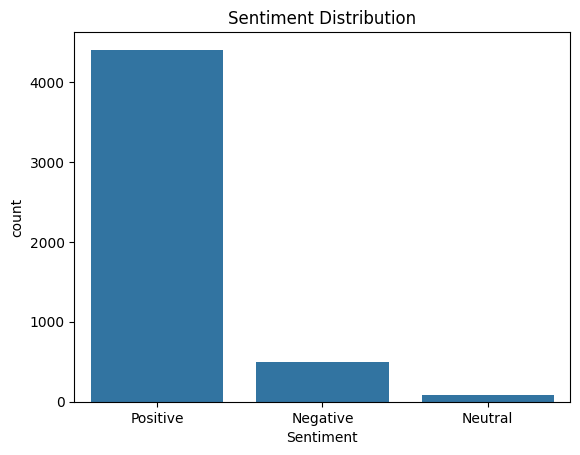

In [27]:
sns.countplot(x='Sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

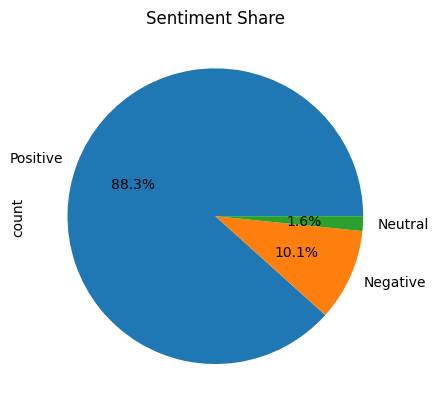

In [40]:
# Pie Chart
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%'),sns.husl_palette
plt.title('Sentiment Share')
plt.show()

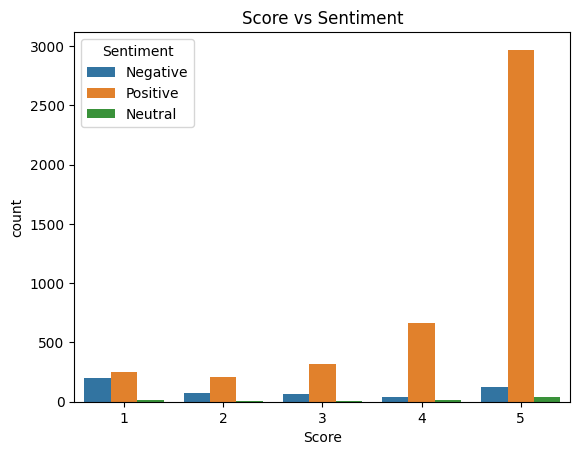

In [38]:
# Score vs Sentiment
sns.countplot(x='Score', hue='Sentiment', data=df)
plt.title('Score vs Sentiment')

plt.show()

In [ ]:
# WordCloud for Negative Reviews
neg_text = ' '.join(df[df['Sentiment']=='Negative']['Text'])
wc = WordCloud(width=800, height=400).generate(neg_text)
plt.imshow(wc)
plt.axis('off')
plt.title('Negative Reviews WordCloud')
plt.show()

## 📌 Insights
- Majority of reviews are Positive.
- Negative reviews highlight product quality & packaging issues.
- Some high ratings still show negative sentiment.
- Recommendation: Improve consistency and packaging quality.
